In [1]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import healpy as hp

In [2]:
HDI=tiff.imread('/home/pratush/Desktop/Actually_the_finalraster_HDI.tif')
HDI_array=np.array(HDI)

In [3]:

#----------Define the spherical coordinates----------#
theta1 = np.linspace(np.radians(0), np.radians(180), num=HDI_array.shape[0],endpoint=False)
phi1 = np.linspace(-np.radians(180), np.radians(180), num=HDI_array.shape[1],endpoint=False)

#---------- Set angular resolution----------#
nside = 128

##--------Make empty healpix mask and pixel values vector--------##
HDI_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts1 = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta1)):
    for j in range(len(phi1)):
        pixel1 = hp.ang2pix(nside, theta1[i], phi1[j])
        HDI_map[pixel1] += HDI_array[i, j]
        pixel_counts1[pixel1] += 1

#--------Average value of each pixel--------#
HDI_map[pixel_counts1>0] /= pixel_counts1[pixel_counts1>0 ]


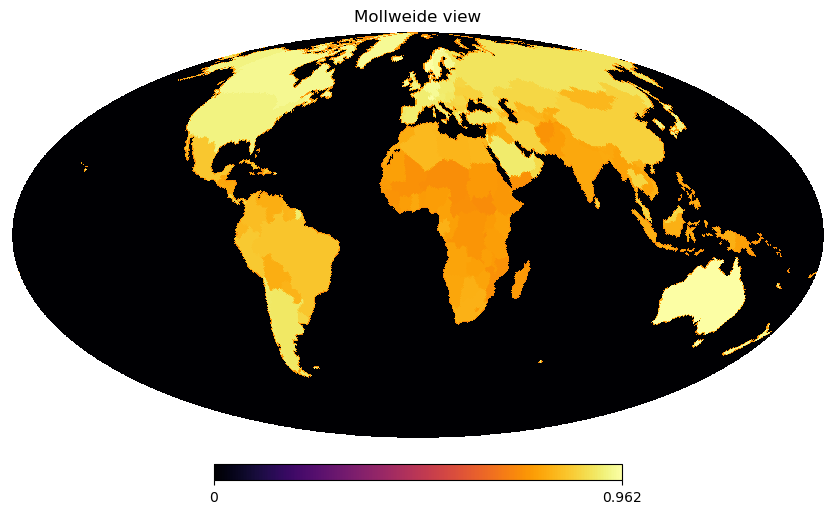

In [4]:

hp.mollview(HDI_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()